# Algoritmos de optimización - Trabajo Práctico<br>
Nombre y Apellidos: Bryan Stalin Sagbay Samamiego  <br>
Url: https://github.com/.../03MAIR---Algoritmos-de-Optimizacion---/tree/master/TrabajoPractico<br>
Google Colab: https://colab.research.google.com/drive/xxxxxxxxxxxxxxxx <br>
Problema:
>1. Sesiones de doblaje <br>
>2. Organizar los horarios de partidos de una jornada de La Liga<br>
>3. Configuración de Tribunales

Descripción del problema:Se precisa coordinar el doblaje de una película. Los actores del doblaje deben coincidir en las tomas en las que sus personajes aparecen juntos en las diferentes tomas. Los actores de doblaje cobran todos la misma cantidad por cada día que deben desplazarse hasta el estudio de grabación independientemente del número de tomas que se graben. No es posible grabar más de 6 tomas por día. El objetivo es planificar las sesiones por día de manera que el gasto por los servicios de los actores de doblaje sea el menor posible. Los datos son:
Número de actores: 10
Número de tomas : 30
Actores/Tomas : https://bit.ly/36D8IuK
- 1 indica que el actor participa en la toma
- 0 en caso contrario               

#Modelo
- ¿Como represento el espacio de soluciones?
- ¿Cual es la función objetivo?
- ¿Como implemento las restricciones?

#### ¿Como represento el espacio de soluciones?
> La solución que se presenta es como un vector de asignación de longitud 30, donde cada posición i indica el día asignado a la toma i:
solucion = [d0, d1, ..., d29]   donde di ∈ {0, 1, 2, 3, 4}
Con 30 tomas y máximo 6 por día necesitamos exactamente 5 días.

#### ¿Cual es la función objetivo?
> El objetivo de la funcion de coste de una planificación se define como el número total de actor-días, es decir, la suma de actores distintos que acuden al estudio cada día.
$$\text{Coste} = \sum_{d=1}^{D} |\text{Actores distintos en día } d|$$
Una solución se representa como una asignación de cada toma a un día.

#### ¿Como implemento las restricciones?
> Se implemnta con la restricción que es máximo 6 tomas por día. Se garantiza que en la generación inicial la distribución controlada de exactamente 6 tomas por día.
En el operador SWAP realizamos el proceso de intercambiar tomas entre días conserva siempre el número por día.

#Análisis
#### ¿Que complejidad tiene el problema?. Orden de complejidad y Contabilizar el espacio de soluciones
>El problema pertenece a la clase NP-hard, siendo equivalente a una variante del Bin Packing Problem. 
El espacio de soluciones válidas (exactamente 6 tomas por día) es: 30! / (6!)^5 ≈ 4.56 × 10^19
Lo que hace inviable la búsqueda exhaustiva y justifica el uso de una metaheurística.

#Diseño
- ¿Que técnica utilizo? ¿Por qué?

Se utiliza Simulated Annealing (SA) por tres razones:

1. **Escapa de mínimos locales**: acepta soluciones peores con probabilidad controlada → evita quedar atrapado.
2. **Eficiencia**: cada iteración O(n), explora miles de configuraciones en segundos.
3. **Calidad**: el enfriamiento lento garantiza refinamiento progresivo.

#### Parámetros del algoritmo

| Parámetro | Valor | Justificación |
|---|---|---|
| Temperatura inicial (T0) | 100 | Alta exploración inicial |
| Temperatura mínima | 0.1 | Criterio de parada |
| Factor enfriamiento (alpha) | 0.995 | Enfriamiento lento = mayor calidad |
| Iteraciones/temperatura | 500 | Exploración suficiente por nivel |

#### Operador de vecindad — SWAP

Selecciona dos tomas de **días distintos** e intercambia sus asignaciones. Siempre produce solución válida (conserva 6 tomas/día).

```
Antes:   dia1=[t1,t2,t3,t4,t5,t6]  dia2=[t7,t8,t9,t10,t11,t12]
SWAP t2 <-> t9
Despues: dia1=[t1,t9,t3,t4,t5,t6]  dia2=[t7,t8,t2,t10,t11,t12]
```

In [2]:
#Imports
import numpy as np
import random
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from copy import deepcopy
import time
import pandas as pd

In [4]:
# Fijar semilla
random.seed(42)
np.random.seed(42)

In [5]:
# Matriz Actores x Tomas (10 actores, 30 tomas)
actores_tomas = np.array([
    [1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
    [0, 0, 1, 1, 1, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 1, 0, 1, 0, 0, 0],
    [1, 1, 0, 0, 0, 0, 1, 1, 0, 0],
    [0, 1, 0, 1, 0, 0, 0, 1, 0, 0],
    [1, 1, 0, 1, 1, 0, 0, 0, 0, 0],
    [1, 1, 0, 1, 1, 0, 0, 0, 0, 0],
    [1, 1, 0, 0, 0, 1, 0, 0, 0, 0],
    [1, 1, 0, 1, 0, 0, 0, 0, 0, 0],
    [1, 1, 0, 0, 0, 1, 0, 0, 1, 0],
    [1, 1, 1, 0, 1, 0, 0, 1, 0, 0],
    [1, 1, 1, 1, 0, 1, 0, 0, 0, 0],
    [1, 0, 0, 1, 1, 0, 0, 0, 0, 0],
    [1, 0, 1, 0, 0, 1, 0, 0, 0, 0],
    [1, 1, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 0, 0, 0, 1],
    [1, 0, 1, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 1, 0, 0, 0, 0],
    [1, 0, 1, 0, 0, 0, 0, 0, 0, 0],
    [1, 0, 1, 1, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 1, 0, 0],
    [1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
    [1, 0, 1, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 1, 0, 0, 0, 0],
    [1, 1, 0, 1, 0, 0, 0, 0, 0, 1],
    [1, 0, 1, 0, 1, 0, 0, 0, 1, 0],
    [0, 0, 0, 1, 1, 0, 0, 0, 0, 0],
    [1, 0, 0, 1, 0, 0, 0, 0, 0, 0],
    [1, 0, 0, 0, 1, 1, 0, 0, 0, 0],
    [1, 0, 0, 1, 0, 0, 0, 0, 0, 0],
])

In [28]:
#Definimos varibles
NUM_TOMAS     = 30
NUM_ACTORES   = 10
MAX_TOMAS_DIA = 6
NUM_DIAS      = NUM_TOMAS // MAX_TOMAS_DIA

print(f'Tomas: {NUM_TOMAS} | Actores: {NUM_ACTORES} | Max tomas / dia: {MAX_TOMAS_DIA} | Min tomas/dia: {NUM_DIAS}')

Tomas: 30 | Actores: 10 | Max tomas / dia: 6 | Min tomas/dia: 5


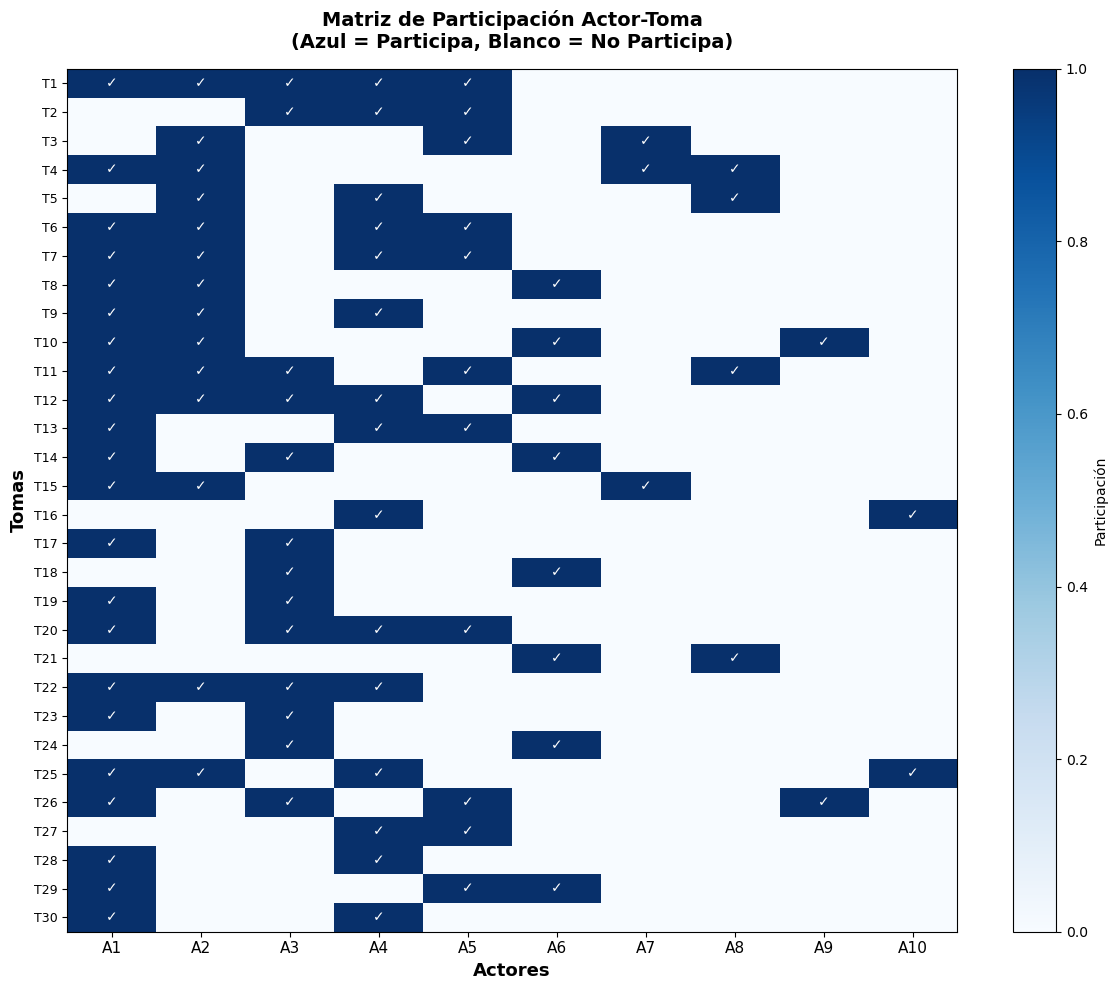

In [29]:
#Vizualisamos que 1 indica que el actor participa en la toma y 0 en caso contrario
fig, ax = plt.subplots(figsize=(12, 10))

img = ax.imshow(actores_tomas, cmap='Blues', aspect='auto', vmin=0, vmax=1)

# Etiquetas
ax.set_xticks(range(NUM_ACTORES))
ax.set_xticklabels([f'A{i+1}' for i in range(NUM_ACTORES)], fontsize=11)
ax.set_yticks(range(NUM_TOMAS))
ax.set_yticklabels([f'T{j+1}' for j in range(NUM_TOMAS)], fontsize=9)

# Añadir valores en las celdas
for i in range(NUM_TOMAS):
    for j in range(NUM_ACTORES):
        color = 'white' if actores_tomas[i, j] == 1 else 'lightgray'
        text = '✓' if actores_tomas[i, j] == 1 else ''
        ax.text(j, i, text, ha='center', va='center', fontsize=10, color=color)

ax.set_xlabel('Actores', fontsize=13, fontweight='bold')
ax.set_ylabel('Tomas', fontsize=13, fontweight='bold')
ax.set_title('Matriz de Participación Actor-Toma\n(Azul = Participa, Blanco = No Participa)',
             fontsize=14, fontweight='bold', pad=15)

plt.colorbar(img, ax=ax, label='Participación')
plt.tight_layout()
plt.show()

In [37]:
# Funcion para calcular el coste
def calcular_coste(solucion):
    """Coste = suma de actores distintos convocados por dia."""
    coste_total = 0
    for dia in range(NUM_DIAS):
        indices = [t for t in range(NUM_TOMAS) if solucion[t] == dia]
        if indices:
            actores_dia = np.any(actores_tomas[indices, :], axis=0)
            coste_total += int(np.sum(actores_dia))
    return coste_total

In [38]:
# Funcion para generar solucion inicila
def generar_solucion_inicial():
    """Solucion aleatoria valida: exactamente 6 tomas por dia."""
    tomas = list(range(NUM_TOMAS))
    random.shuffle(tomas)
    solucion = [0] * NUM_TOMAS
    for dia in range(NUM_DIAS):
        for t in tomas[dia * MAX_TOMAS_DIA:(dia + 1) * MAX_TOMAS_DIA]:
            solucion[t] = dia
    return solucion

In [39]:
# Funcion para generar el vecino
def generar_vecino(solucion):
    """SWAP: intercambia dos tomas de dias distintos (siempre valido)."""
    vecino = solucion[:]
    t1, t2 = random.sample(range(NUM_TOMAS), 2)
    while vecino[t1] == vecino[t2]:
        t1, t2 = random.sample(range(NUM_TOMAS), 2)
    vecino[t1], vecino[t2] = vecino[t2], vecino[t1]
    return vecino

In [40]:
# Validacion
sol_test  = generar_solucion_inicial()
coste_ini = calcular_coste(sol_test)
print(f'Coste solucion inicial aleatoria: {coste_ini} actores-dia')
print(f'Tomas por dia: {[sol_test.count(d) for d in range(NUM_DIAS)]}')

Coste solucion inicial aleatoria: 40 actores-dia
Tomas por dia: [6, 6, 6, 6, 6]


In [46]:
# Algoritmo Simulated Annealing
def simulated_annealing(T_inicial=100, T_min=0.1, alpha=0.995, iter_por_temp=500):
    sol_actual = generar_solucion_inicial()
    coste_actual = calcular_coste(sol_actual)
    mejor_sol = sol_actual[:]
    mejor_coste = coste_actual
    T = T_inicial
    hist_actual = [coste_actual]
    hist_mejor = [mejor_coste]
    iter_total = 0
    acep_mejora = 0
    acep_empeora = 0

    while T > T_min:
        for _ in range(iter_por_temp):
            iter_total += 1
            vecino = generar_vecino(sol_actual)
            coste_vecino = calcular_coste(vecino)
            delta_E = coste_vecino - coste_actual
            if delta_E < 0:
                sol_actual = vecino
                coste_actual = coste_vecino
                acep_mejora += 1
            elif random.random() < math.exp(-delta_E / T):
                sol_actual = vecino
                coste_actual = coste_vecino
                acep_empeora += 1
            if coste_actual < mejor_coste:
                mejor_sol = sol_actual[:]
                mejor_coste = coste_actual
        hist_actual.append(coste_actual)
        hist_mejor.append(mejor_coste)
        T *= alpha

    print(f"Iteraciones totales: {iter_total:,}")
    print(f"Aceptaciones (mejora): {acep_mejora:,}")
    print(f"Aceptaciones (empeora): {acep_empeora:,}")
    print(f"Temperatura final: {T:.4f}")
    print(f"Mejor coste encontrado: {mejor_coste} actores-dia")

    return mejor_sol, mejor_coste, hist_actual, hist_mejor

In [47]:
# Se ejecuta el algoritmo
mejor_sol, mejor_coste, hist_actual, hist_mejor = simulated_annealing()

Iteraciones totales: 689,500
Aceptaciones (mejora): 100,727
Aceptaciones (empeora): 399,642
Temperatura final: 0.0995
Mejor coste encontrado: 27 actores-dia


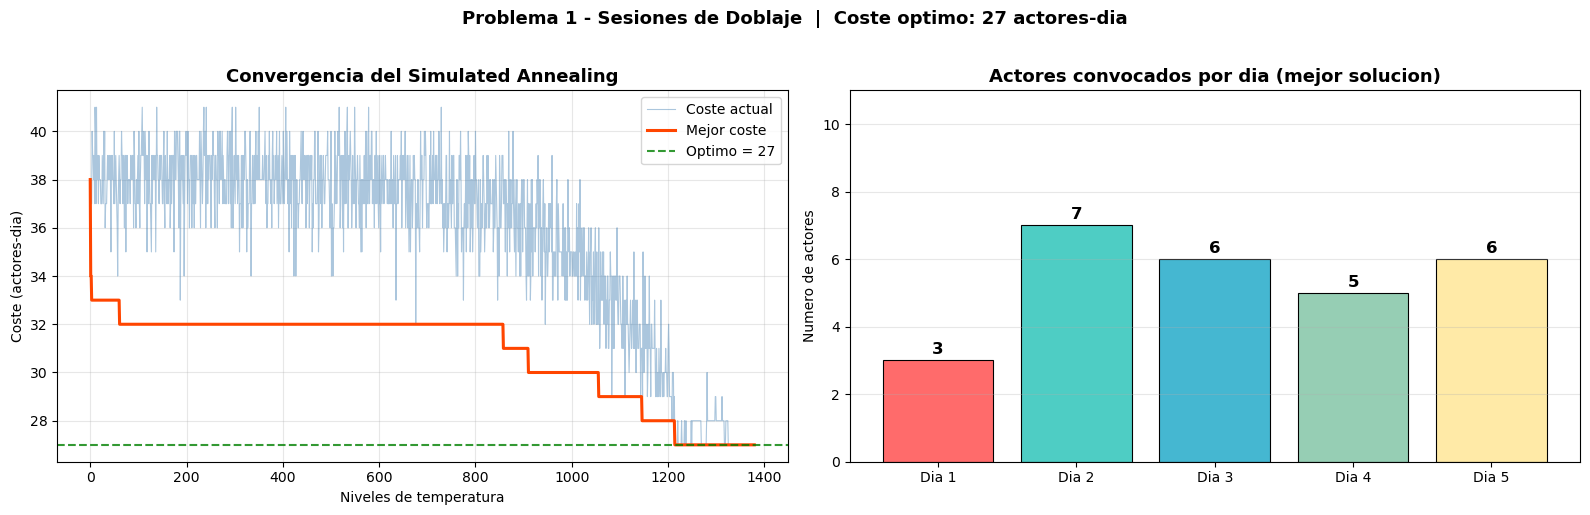

In [54]:
# Visualizacion de Datos obtenidos
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Grafico 1: Convergencia SA
axes[0].plot(hist_actual, color='steelblue', alpha=0.45, linewidth=0.8, label='Coste actual')
axes[0].plot(hist_mejor,  color='orangered', linewidth=2.2, label='Mejor coste')
axes[0].axhline(y=mejor_coste, color='green', linestyle='--', alpha=0.8,
                label=f'Optimo = {mejor_coste}')
axes[0].set_title('Convergencia del Simulated Annealing', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Niveles de temperatura')
axes[0].set_ylabel('Coste (actores-dia)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Grafico 2: Actores convocados por dia
colores = ['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4','#FFEAA7']
actores_por_dia = []
for dia in range(NUM_DIAS):
    idx = [t for t in range(NUM_TOMAS) if mejor_sol[t] == dia]
    actores_por_dia.append(int(np.sum(np.any(actores_tomas[idx, :], axis=0))))

bars = axes[1].bar([f'Dia {d+1}' for d in range(NUM_DIAS)],
                   actores_por_dia, color=colores, edgecolor='black', linewidth=0.8)
axes[1].set_title('Actores convocados por dia (mejor solucion)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Numero de actores')
axes[1].set_ylim(0, NUM_ACTORES + 1)
axes[1].grid(True, axis='y', alpha=0.3)
for bar, val in zip(bars, actores_por_dia):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 str(val), ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.suptitle(f'Problema 1 - Sesiones de Doblaje  |  Coste optimo: {mejor_coste} actores-dia',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [56]:
# Planificacion de tomar y actores
coste_total = 0
for dia in range(NUM_DIAS):
    tomas_dia = sorted([t+1 for t in range(NUM_TOMAS) if mejor_sol[t] == dia])
    indices   = [t-1 for t in tomas_dia]
    actores_p = [i+1 for i in range(NUM_ACTORES) if np.any(actores_tomas[indices, i])]
    coste_dia = len(actores_p)
    coste_total += coste_dia

print(f'COSTE TOTAL OPTIMO: {coste_total} actores-dia')

COSTE TOTAL OPTIMO: 27 actores-dia


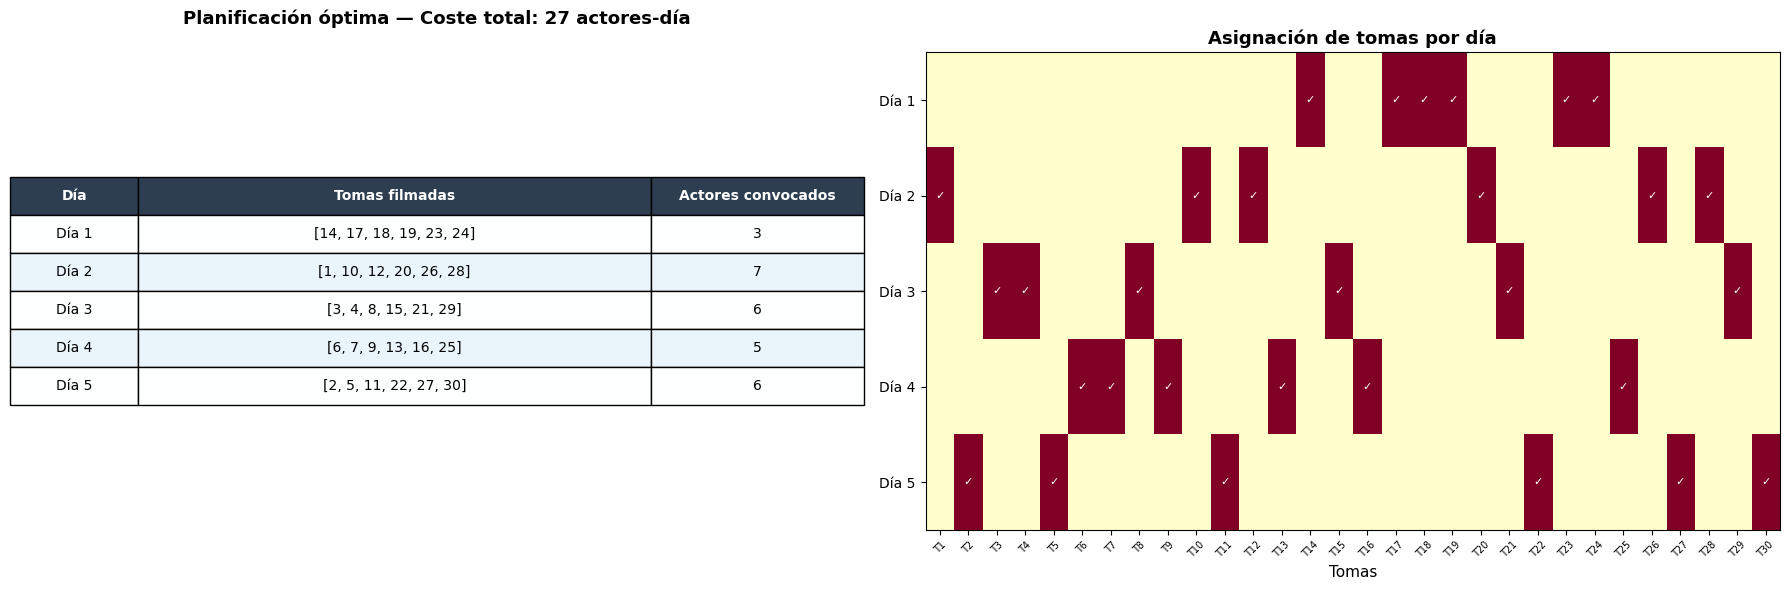

In [58]:
#Representacion Visual de la planificacion 
#Heatmap de asignación tomas → días
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax_tabla = axes[0]
ax_tabla.axis('off')

tabla_datos = [[f'Día {dia+1}',
                str(sorted([t+1 for t in range(NUM_TOMAS) if mejor_sol[t] == dia])),
                len([i for i in range(NUM_ACTORES)
                     if np.any(actores_tomas[[t for t in range(NUM_TOMAS) if mejor_sol[t] == dia], i])])]
               for dia in range(NUM_DIAS)]

tabla = ax_tabla.table(
    cellText=tabla_datos,
    colLabels=['Día', 'Tomas filmadas', 'Actores convocados'],
    cellLoc='center',
    loc='center',
    colWidths=[0.15, 0.6, 0.25]
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(10)
tabla.scale(1, 2.2)

for j in range(3):
    tabla[0, j].set_facecolor('#2c3e50')
    tabla[0, j].set_text_props(color='white', fontweight='bold')

colores_fila = ['#EAF4FB', '#FDFEFE']
for i in range(1, NUM_DIAS + 1):
    for j in range(3):
        tabla[i, j].set_facecolor(colores_fila[i % 2])

ax_tabla.set_title(f'Planificación óptima — Coste total: {mejor_coste} actores-día',
                   fontsize=13, fontweight='bold', pad=20)

#Heatmap tomas x días
ax_heat = axes[1]
matriz_asig = np.zeros((NUM_DIAS, NUM_TOMAS))
for t in range(NUM_TOMAS):
    matriz_asig[mejor_sol[t], t] = 1

im = ax_heat.imshow(matriz_asig, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
ax_heat.set_xticks(range(NUM_TOMAS))
ax_heat.set_xticklabels([f'T{t+1}' for t in range(NUM_TOMAS)], fontsize=7, rotation=45)
ax_heat.set_yticks(range(NUM_DIAS))
ax_heat.set_yticklabels([f'Día {d+1}' for d in range(NUM_DIAS)], fontsize=10)
ax_heat.set_title('Asignación de tomas por día', fontsize=13, fontweight='bold')
ax_heat.set_xlabel('Tomas', fontsize=11)

for d in range(NUM_DIAS):
    for t in range(NUM_TOMAS):
        if matriz_asig[d, t] == 1:
            ax_heat.text(t, d, '✓', ha='center', va='center', fontsize=8, color='white', fontweight='bold')

plt.tight_layout()
plt.show()